<a href="https://colab.research.google.com/github/valliansayoga/ey-data-challenge-2025/blob/master/EY2025_Create_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://challenge.ey.com/api/v1/storage/admin-files/556750475068843-678f9918ed9624f63ca75b56-Dataset.zip

--2025-01-27 05:45:52--  https://challenge.ey.com/api/v1/storage/admin-files/556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
Resolving challenge.ey.com (challenge.ey.com)... 52.236.158.32
Connecting to challenge.ey.com (challenge.ey.com)|52.236.158.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13861358 (13M) [application/octet-stream]
Saving to: ‘556750475068843-678f9918ed9624f63ca75b56-Dataset.zip’

556750475068843-678 100%[===================>]  13.22M  8.11MB/s    in 1.6s    

2025-01-27 05:45:54 (8.11 MB/s) - ‘556750475068843-678f9918ed9624f63ca75b56-Dataset.zip’ saved [13861358/13861358]



In [ ]:
!unzip 556750475068843-678f9918ed9624f63ca75b56-Dataset.zip

Archive:  556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
   creating: Dataset/
  inflating: Dataset/2025 EY Open Science AI Data Challenge Participant Guidance.pdf  
  inflating: Dataset/Building_Footprint.kml  
  inflating: Dataset/Landsat_LST.ipynb  
  inflating: Dataset/NY_Mesonet_Weather.xlsx  
  inflating: Dataset/Sentinel2_GeoTIFF.ipynb  
  inflating: Dataset/Submission_template.csv  
  inflating: Dataset/Training_data_uhi_index.csv  
  inflating: Dataset/UHI Experiment Sample Benchmark Notebook V5.ipynb  


In [ ]:
!python -m pip install \
    xarray \
    rioxarray \
    rasterio \
    stackstac \
    pystac_client \
    pystac==1.11.0 \
    planetary_computer \
    odc-stac \
    osmnx \
    pykml \
    geopandas \
    shapely \
    fiona \
    --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.8/153.8 kB 9.7 MB/s eta 0:00:00


In [ ]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import jet,RdYlGn

# Import Planetary Computer tools
import stackstac
import pystac_client
import planetary_computer
from odc.stac import stac_load, load
import pandas as pd

In [ ]:
date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv("/content/Dataset/Training_data_uhi_index.csv", date_format=date_format,
                 parse_dates=["datetime"])
df.head()

In [ ]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Longitude  11229 non-null  float64       
 1   Latitude   11229 non-null  float64       
 2   datetime   11229 non-null  datetime64[ns]
 3   UHI Index  11229 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 351.0 KB


In [ ]:
df.Latitude.agg(["max", "min"])

,Latitude
max,40.859497
min,40.758792


In [ ]:
df.Longitude.agg(["max", "min"])

,Longitude
max,-73.879458
min,-73.994457


In [ ]:
time_window = "2021-06-01/2021-08-01"
time_window

'2021-06-01/2021-08-01'

In [ ]:
lower_left = (40.75, -74.01)  # (long, lat)
upper_right = (40.88, -73.86)

In [ ]:
# bounds = (min_lon, min_lat, max_lon, max_lat)
bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
print(bounds)

(-74.01, 40.75, -73.86, 40.88)


# Client

In [ ]:
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

search = stac.search(
    bbox=bounds,
    datetime=time_window,
    collections=["landsat-c2-l2"],
    query={"eo:cloud_cover": {"lt": 30},"platform": {"in": ["landsat-8"]}},
)
items = list(search.get_items())
print('Identified items:', len(items))

Identified items: 5


In [ ]:
signed_items = [planetary_computer.sign(item).to_dict() for item in items]
resolution = 10  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

In [ ]:
items = search.get_all_items()

In [ ]:
list(map(lambda item: {item.properties["datetime"]: item.properties["eo:cloud_cover"]}, items))

[{'2021-06-23T15:39:44.720711Z': 14.26},
 {'2021-06-23T15:39:20.838143Z': 23.89},
 {'2021-06-16T15:33:32.108022Z': 7.46},
 {'2021-06-07T15:39:39.787469Z': 24.54},
 {'2021-06-07T15:39:15.904901Z': 6.88}]

In [ ]:
data1 = stac_load(
    items,
    bands=["red", "green", "blue", "nir08"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)
data2 = stac_load(
    items,
    bands=["lwir11"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)

In [ ]:
display(data1)
display(data2)

<xarray.Dataset> Size: 97MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 5)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 40B 2021-06-07T15:39:15.904901 ... 202...
Data variables:
    red          (time, latitude, longitude) uint16 24MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 24MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 24MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    nir08        (time, latitude, longitude) uint16 24MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

<xarray.Dataset> Size: 24MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 5)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 40B 2021-06-07T15:39:15.904901 ... 202...
Data variables:
    lwir11       (time, latitude, longitude) uint16 24MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

In [ ]:
# Persist the data in memory for faster operations
data1 = data1.persist()
data2 = data2.persist()

In [ ]:
# Scale Factors for the RGB and NIR bands
scale1 = 0.0000275
offset1 = -0.2
data1 = data1.astype(np.float64) * scale1 + offset1

# Scale Factors for the Surface Temperature band
scale2 = 0.00341802
offset2 = 149.0
kelvin_celsius = 273.15 # convert from Kelvin to Celsius
data2 = data2.astype(float) * scale2 + offset2 - kelvin_celsius

In [ ]:
data1 = data1[["red", "green", "blue", "nir08"]].median(dim="time")  # Getting the median

# NDVI Median

In [ ]:
ndvi = (data1.nir08 - data1.red) / (data1.nir08 + data1.red)

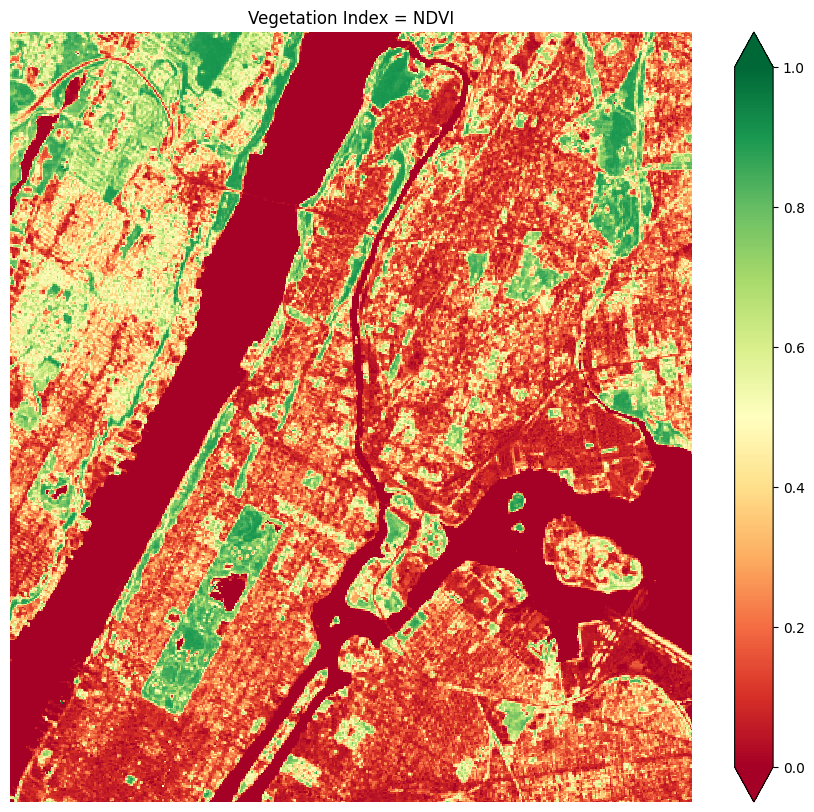

In [ ]:
fig, ax = plt.subplots(figsize=(11,10))
ndvi.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")
plt.title("Vegetation Index = NDVI")
plt.axis('off')
plt.show()

# Temp Median

In [ ]:
lwir_median = data2.lwir11.median(dim="time")

In [ ]:
from pathlib import Path

def export_to_tif(item, output_name, lower_left, upper_right, crs="epsg:4326", count=None):
    # Creating Dir if not exists
    path = Path(output_name)
    path.resolve().parents[0].mkdir(parents=True, exist_ok=True)

    height = item.sizes["latitude"]
    width = item.sizes["longitude"]
    gt = rasterio.transform.from_bounds(
        lower_left[1],
        lower_left[0],
        upper_right[1],
        upper_right[0],
        width,
        height
    )
    item.rio.write_crs(crs, inplace=True)
    item.rio.write_transform(transform=gt, inplace=True)

    with rasterio.open(output_name, "w", driver="GTiff", width=width,
                       height=height, crs=crs, transform=gt, count=count,
                       compress="lzw", dtype="float64") as dst:
        if hasattr(item, "to_dataarray"):
            dst.write(item.to_dataarray())
            return

        if len(item.shape) == 2:
            dst.write(item.values.reshape(1, height, width))
            return

        else:
            dst.write(item)
            return

In [ ]:
filename = f"Train/rgb_nir_median_scale{scale}.tiff"
export_to_tif(data1, filename, lower_left, upper_right, count=4)

In [ ]:
filename = f"Train/ndvi_median_scale{scale}.tiff"
export_to_tif(ndvi, filename, lower_left, upper_right, count=1)

In [ ]:
filename = f"Train/temp_median_scale{scale}.tiff"
export_to_tif(lwir_median, filename, lower_left, upper_right, count=1)

In [ ]:
# Only select one of the time slices to output
filename = f"rgb_nir_median_scale{scale}.tiff"

# Calculate the dimensions of the file
height = data1.dims["latitude"]
width = data1.dims["longitude"]

# Define the Coordinate Reference System (CRS) to be common Lat-Lon coordinates
# Define the tranformation using our bounding box so the Lat-Lon information is written to the GeoTIFF
gt = rasterio.transform.from_bounds(lower_left[1],lower_left[0],upper_right[1],upper_right[0],width,height)
data1.rio.write_crs("epsg:4326", inplace=True)
data1.rio.write_transform(transform=gt, inplace=True);

# Create the GeoTIFF output file using the defined parameters
with rasterio.open(filename,'w',driver='GTiff',width=width,height=height,
                   crs='epsg:4326',transform=gt, count=4, compress='lzw', dtype='float64') as dst:
    dst.write(data1.squeeze()[["red", "green", "blue", "nir08"]].to_dataarray())
    dst.close()

In [ ]:
# Only select one of the time slices to output
filename = f"ndvi_median_scale{scale}.tiff"

# Calculate the dimensions of the file
height = ndvi.shape[0]
width = ndvi.shape[1]

# Define the Coordinate Reference System (CRS) to be common Lat-Lon coordinates
# Define the tranformation using our bounding box so the Lat-Lon information is written to the GeoTIFF
gt = rasterio.transform.from_bounds(lower_left[1],lower_left[0],upper_right[1],upper_right[0],width,height)
# ndvi.rio.write_crs("epsg:4326", inplace=True)
# ndvi.rio.write_transform(transform=gt, inplace=True);

# Create the GeoTIFF output file using the defined parameters
with rasterio.open(filename,'w',driver='GTiff',width=width,height=height,
                   crs='epsg:4326',transform=gt, count=1, compress='lzw', dtype='float64') as dst:
    dst.write(ndvi, 1)
    dst.close()

In [ ]:
lwir_median.shape

(4728, 5455)

In [ ]:
# Only select one of the time slices to output
filename = f"temp_median_{scale}.tiff"

# Calculate the dimensions of the file
height = lwir_median.shape[0]
width = lwir_median.shape[1]

# Define the Coordinate Reference System (CRS) to be common Lat-Lon coordinates
# Define the tranformation using our bounding box so the Lat-Lon information is written to the GeoTIFF
gt = rasterio.transform.from_bounds(lower_left[1],lower_left[0],upper_right[1],upper_right[0],width,height)
lwir_median.rio.write_crs("epsg:4326", inplace=True)
lwir_median.rio.write_transform(transform=gt, inplace=True);

# Create the GeoTIFF output file using the defined parameters
with rasterio.open(filename,'w',driver='GTiff',width=width,height=height,
                   crs='epsg:4326',transform=gt, count=1, compress='lzw', dtype='float64') as dst:
    dst.write(lwir_median.values.reshape(1, height, width))
    dst.close()

# Building Features

In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from fiona.drvsupport import supported_drivers
from tqdm import tqdm
import pandas as pd


def calculate_average_distance_to_N_polygons(row, polygons, N):
    """Calculate the average distance to the nearest N polygons for a given point (row) using spatial indexing."""
    point = row.geometry
    sindex = polygons.sindex

    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    sorted_distances = sorted(distances)[:N]
    return np.mean(sorted_distances)

def calculate_std_distance_to_N_polygons(row, polygons, N):
    """Calculate the std distance to the nearest N polygons for a given point (row) using spatial indexing."""
    point = row.geometry
    sindex = polygons.sindex

    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    sorted_distances = sorted(distances)[:N]
    return np.std(sorted_distances)

def calculate_building_density(row, polygons, buffer_radius):
    """Calculate building density (number of building footprints per unit area) within a buffer zone around the point."""
    point = row.geometry
    buffer_zone = point.buffer(buffer_radius)
    nearby_buildings = polygons[polygons.intersects(buffer_zone)]
    density = len(nearby_buildings) / buffer_zone.area
    return density

def calculate_building_area_density(row, polygons, buffer_radius):
    """Calculate building area density within a buffer zone around the point."""
    point = row.geometry
    buffer_zone = point.buffer(buffer_radius)
    nearby_buildings = polygons[polygons.intersects(buffer_zone)]
    total_area = nearby_buildings.geometry.area.sum()
    return total_area / buffer_zone.area

def calculate_nearest_building_size(row, polygons):
    """Calculate the area of the nearest building polygon to the point."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute the distance to the nearest polygon (there should be just one polygon)
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]
    return nearest_polygon.area

def calculate_neighboring_polygon_intersection(row, polygons):
    """Calculate the intersection of the nearest polygon with its neighboring polygons."""
    point = row.geometry
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()  # Adjust num_results as necessary
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]

    # Find neighboring polygons that intersect the nearest polygon
    neighbors = polygons[polygons.intersects(nearest_polygon)]
    intersection_area = nearest_polygon.intersection(unary_union(neighbors)).area
    return intersection_area

def calculate_point_relative_position_to_building_boundary(row, polygons):
    """Determine if the point is closer to the edge, center, or corners of the building polygon."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()   # Adjust num_results as needed
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]

    # Determine the relative position to the nearest polygon's boundary
    boundary_distance = point.distance(nearest_polygon.boundary)
    centroid_distance = point.distance(nearest_polygon.centroid)

    if boundary_distance < centroid_distance:
        return 1 # "1st (closer to edge)"
    elif boundary_distance > centroid_distance:
        return 2 # "2nd (closer to center)"
    else:
        return 3 # "3rd (equidistant)"

def calculate_nearest_polygon_angle(row, polygons):
    """Calculate the angle of the point relative to the orientation of the nearest polygon."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()   # Only 1 nearest match
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]

    # Calculate the angle relative to the centroid of the nearest polygon
    centroid = nearest_polygon.centroid
    angle = np.arctan2(centroid.y - point.y, centroid.x - point.x)
    return np.degrees(angle)

def calculate_variation_in_distance_to_multiple_polygons(row, polygons, N):
    """Calculate the standard deviation or range of distances to the N nearest polygons."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()   # Adjust num_results as necessary
    possible_matches_index[::-1].sort()   # Adjust num_results as necessary
    possible_matches = polygons.iloc[possible_matches_index[:N]]

    # Compute distances to the filtered set of polygons
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    sorted_distances = sorted(distances)[:N]
    return np.std(sorted_distances), np.ptp(sorted_distances)  # standard deviation and range

def calculate_nearest_polygon_shape_avg_complexity(row, polygons):
    """Calculate the average complexity of the nearest polygon's shape using the number of vertices or fractal dimension."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()  # Adjust num_results as necessary
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]
    # Calculate the number of vertices of the nearest polygon
    avg_vertices = np.array([np.array(geom.exterior.coords.xy[0]).shape[0] for geom in nearest_polygon.geoms]).mean()
    return avg_vertices


In [ ]:
def get_point(row):
    return Point(row["Longitude"], row["Latitude"])

def create_building_features(
    df,
    min_distance,
    max_distance,
    step,
    buffer_radius=50,  # meter
    N=5, # N buildings
):
    print("Loading footprint...")
    epsg_distance = "32633"
    epsg_read = "4326"
    supported_drivers['LIBKML'] = 'rw'
    my_map = gpd.read_file('/content/Dataset/Building_Footprint.kml', driver='LIBKML')
    my_map.to_crs(epsg=epsg_distance, inplace=True)

    print("Creating points...")
    geometric_points = df.apply(get_point, axis=1).to_numpy().tolist()
    geo_locations = gpd.GeoDataFrame(
        df,
        crs=f'epsg:{epsg_read}',
        geometry = geometric_points
    )
    geo_locations.to_crs(epsg=epsg_distance, inplace=True)

    print("Adding 'is_building'...")
    is_building = list()
    for i in range(0, len(geo_locations)):
        point = geo_locations.geometry.loc[i]
        check = any(my_map.contains(point).values)
        is_building.append(check)
    geo_locations["is_a_building"] = list(map(int, is_building))

    print("Calculating nearest bulding distance...")
    assert geo_locations.crs == my_map.crs, "CRS must match!"
    geo_locations['nearest_building_distance'] = geo_locations.apply(
        lambda row: my_map.distance(row.geometry).min(), axis=1
    )

    print("Counting buildings near threshold...")
    threshold_distances = tqdm(list(range(min_distance, max_distance+step, step))) # meters
    # Nearest bulding count of x meter distance
    for distance in threshold_distances:
        geo_locations[f'{distance}m_nearby_building_count'] = geo_locations.apply(
            lambda row: my_map[my_map.geometry.intersects(row.geometry.buffer(distance))].shape[0], axis=1
        )
    print("Calculating 'average_distance...")
    geo_locations['average_distance'] = geo_locations.apply(calculate_average_distance_to_N_polygons, axis=1, polygons=my_map.geometry, N=N)

    print("Calculating 'std_distance...")
    geo_locations['std_distance'] = geo_locations.apply(calculate_std_distance_to_N_polygons, axis=1, polygons=my_map.geometry, N=N)

    print("Calculating 'building_density...")
    geo_locations['building_density'] = geo_locations.apply(calculate_building_density, axis=1, polygons=my_map, buffer_radius=buffer_radius)

    print("Calculating 'building_area_density...")
    geo_locations['building_area_density'] = geo_locations.apply(calculate_building_area_density, axis=1, polygons=my_map, buffer_radius=buffer_radius)

    print("Calculating 'nearest_building_size...")
    geo_locations['nearest_building_size'] = geo_locations.apply(calculate_nearest_building_size, axis=1, polygons=my_map.geometry)

    print("Calculating 'neighboring_intersection...")
    geo_locations['neighboring_intersection'] = geo_locations.apply(calculate_neighboring_polygon_intersection, axis=1, polygons=my_map.geometry)

    print("Calculating 'relative_position...")
    geo_locations['relative_position'] = geo_locations.apply(calculate_point_relative_position_to_building_boundary, axis=1, polygons=my_map.geometry)

    print("Calculating 'nearest_polygon_angle...")
    geo_locations['nearest_polygon_angle'] = geo_locations.apply(calculate_nearest_polygon_angle, axis=1, polygons=my_map.geometry)

    print("Calculating 'distance_variation...")
    geo_locations['distance_variation'], geo_locations['distance_range'] = zip(*geo_locations.apply(calculate_variation_in_distance_to_multiple_polygons, axis=1, polygons=my_map.geometry, N=N))

    print("Calculating 'avg_polygon_complexity...")
    geo_locations['avg_polygon_complexity'] = geo_locations.apply(calculate_nearest_polygon_shape_avg_complexity, axis=1, polygons=my_map.geometry)


    print("Done!")
    return geo_locations

In [ ]:
date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv(
    "/content/Dataset/Training_data_uhi_index.csv",
    date_format=date_format,
    parse_dates=["datetime"]
)
df_building_train = create_building_features(
    df,
    min_distance=10,
    max_distance=50,
    step=10,
    buffer_radius=50,  # meter
    N=5, # N buildings
)
df_building_train

Loading footprint...
Creating points...
Adding 'is_building'...
Calculating nearest bulding distance...


/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Counting buildings near threshold...


100%|██████████| 5/5 [01:27<00:00, 17.56s/it]


Calculating 'average_distance...


...

/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Calculating 'avg_polygon_complexity...


/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Done!


,Longitude,Latitude,datetime,UHI Index,geometry,is_a_building,nearest_building_distance,10m_nearby_building_count,20m_nearby_building_count,30m_nearby_building_count,...,std_distance,building_density,building_area_density,nearest_building_size,neighboring_intersection,relative_position,nearest_polygon_angle,distance_variation,distance_range,avg_polygon_complexity
0,-73.909167,40.813107,2021-07-24 15:53:00,1.030289,POINT (-5804933.414 9857596.811),0,19.079136,0,1,1,...,3010.415846,0.000128,1.834324,14383.618621,14383.618621,1,-157.415935,3010.415846,6020.831692,29.0
1,-73.909187,40.813045,2021-07-24 15:53:00,1.030289,POINT (-5804943.928 9857599.08),0,19.233293,0,1,1,...,3015.153812,0.000128,1.834324,14383.618621,14383.618621,1,-153.907970,3015.153812,6030.307623,29.0
2,-73.909215,40.812978,2021-07-24 15:53:00,1.023798,POINT (-5804955.321 9857602.397),0,20.268009,0,0,1,...,3019.750278,0.000128,1.834324,14383.618621,14383.618621,1,-148.916535,3019.750278,6039.500556,29.0
3,-73.909242,40.812908,2021-07-24 15:53:00,1.023798,POINT (-5804967.271 9857605.484),0,20.968705,0,0,1,...,3024.815152,0.000255,2.163022,14383.618621,14383.618621,1,-142.868592,3024.815152,6049.630304,29.0
4,-73.909257,40.812845,2021-07-24 15:53:00,1.021634,POINT (-5804978.048 9857607.103),0,16.324876,0,1,1,...,3032.165299,0.000255,2.163022,14383.618621,14383.618621,1,-137.014238,3032.165299,6064.330598,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,2021-07-24 15:57:00,0.972470,POINT (-5808964.468 9863649.01),0,295.759464,0,0,0,...,5294.605081,0.000000,0.000000,2701.882019,2701.882019,1,68.494987,5294.605081,10589.210161,9.0
11225,-73.957063,40.790308,2021-07-24 15:57:00,0.972470,POINT (-5808968.75 9863650.609),0,295.705141,0,0,0,...,5296.911189,0.000000,0.000000,2701.882019,2701.882019,1,67.760171,5296.911189,10593.822377,9.0
11226,-73.957093,40.790270,2021-07-24 15:57:00,0.981124,POINT (-5808975.349 9863654.291),0,294.627364,0,0,0,...,5301.217502,0.000000,0.000000,2701.882019,2701.882019,1,66.551033,5301.217502,10602.435004,9.0
11227,-73.957112,40.790253,2021-07-24 15:59:00,0.981245,POINT (-5808978.238 9863656.573),0,293.594965,0,0,0,...,5303.523507,0.000000,0.000000,2701.882019,2701.882019,1,65.975980,5303.523507,10607.047014,9.0


In [ ]:
df_building_train.groupby("10m_nearby_building_count")["UHI Index"].agg(["mean", "max", "min", "median", "count"])

In [ ]:
sub_df = pd.read_csv(
    "/content/Dataset/Submission_template.csv",
)
df_building_submission = create_building_features(
    sub_df,
    min_distance=10,
    max_distance=50,
    step=10,
    buffer_radius=50,  # meter
    N=5, # N buildings
)

Loading footprint...
Creating points...
Adding 'is_building'...
Calculating nearest bulding distance...


/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Counting buildings near threshold...


100%|██████████| 5/5 [00:08<00:00,  1.77s/it]
/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Calculating 'average_distance...
Calculating 'std_distance...


...

Calculating 'distance_variation...


/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Calculating 'avg_polygon_complexity...


/usr/local/lib/python3.11/dist-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Done!


In [ ]:
df_building_train.head().iloc[:, 5:]

,is_a_building,nearest_building_distance,10m_nearby_building_count,20m_nearby_building_count,30m_nearby_building_count,40m_nearby_building_count,50m_nearby_building_count,average_distance,std_distance,building_density,building_area_density,nearest_building_size,neighboring_intersection,relative_position,nearest_polygon_angle,distance_variation,distance_range,avg_polygon_complexity
0,0,19.079136,0,1,1,1,1,3029.494982,3010.415846,0.000128,1.834324,14383.618621,14383.618621,1,-157.415935,3010.415846,6020.831692,29.0
1,0,19.233293,0,1,1,1,1,3034.387105,3015.153812,0.000128,1.834324,14383.618621,14383.618621,1,-153.907970,3015.153812,6030.307623,29.0
2,0,20.268009,0,0,1,1,1,3040.018287,3019.750278,0.000128,1.834324,14383.618621,14383.618621,1,-148.916535,3019.750278,6039.500556,29.0
3,0,20.968705,0,0,1,1,2,3045.783857,3024.815152,0.000255,2.163022,14383.618621,14383.618621,1,-142.868592,3024.815152,6049.630304,29.0
4,0,16.324876,0,1,1,2,2,3048.490175,3032.165299,0.000255,2.163022,14383.618621,14383.618621,1,-137.014238,3032.165299,6064.330598,29.0


In [ ]:
df_building_submission.head().iloc[:, 4:]

,is_a_building,nearest_building_distance,10m_nearby_building_count,20m_nearby_building_count,30m_nearby_building_count,40m_nearby_building_count,50m_nearby_building_count,average_distance,std_distance,building_density,building_area_density,nearest_building_size,neighboring_intersection,relative_position,nearest_polygon_angle,distance_variation,distance_range,avg_polygon_complexity
0,0,23.299040,0,0,2,2,2,6042.186582,6018.887543,0.000255,2.331297,3042.483042,3042.483042,1,-41.149765,6018.887543,12037.775086,7.0
1,0,22.348917,0,0,2,2,3,6043.315623,6020.966706,0.000383,2.713871,3042.483042,3042.483042,1,-78.519555,6020.966706,12041.933412,7.0
2,1,0.000000,1,1,1,1,1,5848.496550,5848.496550,0.000128,2.214722,17366.455105,17366.455105,1,78.274187,5848.496550,11696.993101,19.0
3,0,0.797466,1,1,1,2,3,6040.553905,6039.756439,0.000383,2.550029,3463.041818,3463.041818,1,-170.046269,6039.756439,12079.512878,9.0
4,0,14.437841,0,2,2,2,2,6025.964543,6011.526702,0.000255,7.422946,32671.490686,32671.490686,1,-69.165232,6011.526702,12023.053405,9.0


In [ ]:
df_building_train.iloc[:, 5:].to_csv("Train_Building_Features.csv", index=False)

In [ ]:
df_building_submission.iloc[:, 4:].to_csv("Submission_Building_Features.csv", index=False)